In [15]:
import math
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# --- GLOBAL KNAPSACK SETTINGS ---
NUM_ITEMS = 50
POPULATION_SIZE = 100
MAX_GENERATIONS = 100

# Generate a static Knapsack problem so all algorithms solve the exact same instance
np.random.seed(42)
WEIGHTS = np.random.randint(1, 20, NUM_ITEMS)
VALUES = np.random.randint(10, 100, NUM_ITEMS)
CAPACITY = np.sum(WEIGHTS) * 0.5

# --- META-GA TUNED PARAMETERS ---
# (You will replace these after running Cell 4)
TUNED_A_INIT = 0.518
TUNED_R_INIT = 0.422
TUNED_F_MAX = 1.143    
TUNED_ALPHA = 0.898   
TUNED_GAMMA = 0.097
''' 


--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---
TUNED_A_INIT = 0.850
TUNED_R_INIT = 0.150
TUNED_F_MAX = 1.200    
TUNED_ALPHA = 0.980    
TUNED_GAMMA = 0.040


A_INIT: 0.518 | R_INIT: 0.422 | F_MAX: 1.143
ALPHA:  0.898 | GAMMA:  0.097
Average Profit with these settings: $1807.00
'''

' \n\n\n--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---\nTUNED_A_INIT = 0.850\nTUNED_R_INIT = 0.150\nTUNED_F_MAX = 1.200    \nTUNED_ALPHA = 0.980    \nTUNED_GAMMA = 0.040\n\n\nA_INIT: 0.518 | R_INIT: 0.422 | F_MAX: 1.143\nALPHA:  0.898 | GAMMA:  0.097\nAverage Profit with these settings: $1807.00\n'

In [16]:
def fitness_knapsack(solution):
    """Evaluates the binary array. Returns a NEGATIVE value (to minimize profit)."""
    total_weight = np.sum(solution * WEIGHTS)
    total_value = np.sum(solution * VALUES)
    
    if total_weight > CAPACITY:
        # Fatal Penalty constraint
        return 10000 + (total_weight - CAPACITY) * 100 
    return -total_value

def smart_initialization_knapsack(pop_size, num_items):
    """Spawns 80% random bats, and 20% heuristically optimized bats."""
    positions = []
    for _ in range(int(pop_size * 0.8)):
        positions.append(np.random.randint(0, 2, num_items))
        
    # Heuristic: Greedy initialization using Value/Weight ratio
    # FIX: Uses the current global WEIGHTS and VALUES arrays correctly
    ratios = VALUES[:num_items] / WEIGHTS[:num_items]
    sorted_indices = np.argsort(ratios)[::-1]
    
    for _ in range(int(pop_size * 0.2)):
        greedy_sack = np.zeros(num_items)
        current_weight = 0
        for idx in sorted_indices:
            if current_weight + WEIGHTS[idx] <= CAPACITY and random.random() > 0.1:
                greedy_sack[idx] = 1
                current_weight += WEIGHTS[idx]
        positions.append(greedy_sack)
        
    return np.array(positions, dtype=float)

In [17]:
def genetic_algorithm(n_items=NUM_ITEMS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """Baseline GA using Uniform Crossover and Bit-Flip Mutation."""
    population = [np.random.randint(0, 2, n_items) for _ in range(pop_size)]
    best_fitness = float('inf')
    best_ind = None
    convergence = []
    
    for generation in range(max_gens):
        fitness_scores = [fitness_knapsack(ind) for ind in population]
        min_fit = min(fitness_scores)
        if min_fit < best_fitness: 
            best_fitness = min_fit
            best_ind = population[fitness_scores.index(min_fit)].copy()
        convergence.append(-best_fitness if best_fitness < 0 else 0)
            
        new_population = []
        for _ in range(pop_size // 2):
            t1 = random.sample(list(zip(population, fitness_scores)), 3)
            t2 = random.sample(list(zip(population, fitness_scores)), 3)
            p1, p2 = min(t1, key=lambda x: x[1])[0], min(t2, key=lambda x: x[1])[0]
            
            mask = np.random.randint(0, 2, n_items)
            c1, c2 = np.where(mask, p1, p2), np.where(mask, p2, p1)
            new_population.extend([c1, c2])
            
        for i in range(pop_size):
            if random.random() < 0.1:
                flip_idx = random.randint(0, n_items-1)
                new_population[i][flip_idx] = 1 - new_population[i][flip_idx]
        population = new_population
    return best_fitness, convergence, best_ind, fitness_scores

def standard_bat_algorithm(n_items=NUM_ITEMS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """V1 BA using Sigmoid Transfer and continuous random walk."""
    positions = np.array([np.random.randint(0, 2, n_items) for _ in range(pop_size)], dtype=float)
    velocities = np.zeros((pop_size, n_items))
    A, r = np.ones(pop_size) * 0.9, np.ones(pop_size) * 0.3
    fitness = np.array([fitness_knapsack(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            velocities[i] += (positions[i] - best_position) * random.uniform(0, 2.0)
            if random.random() > r[i]:
                new_pos_cont = best_position + np.random.uniform(-1, 1, n_items) * np.mean(A)
                new_pos = np.where(new_pos_cont > 0.5, 1, 0)
            else:
                sigmoid = 1 / (1 + np.exp(-velocities[i]))
                new_pos = np.where(np.random.random(n_items) < sigmoid, 1, 0)
                
            new_fit = fitness_knapsack(new_pos)
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
            curr_div += np.sum(positions[i] != best_position)
            
        convergence.append(-best_fitness if best_fitness < 0 else 0)
        diversity.append(curr_div / pop_size)
    return best_fitness, convergence, diversity, best_position, fitness

def enhanced_bat_algorithm(n_items=NUM_ITEMS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS, init_pop=None, a_init=0.9, r_init=0.3, f_max=2.0, alpha=0.9, gamma=0.05):
    """V2 BA using Tuned Sigmoid constraints and Memetic Bit-Flip."""
    positions = init_pop.copy() if init_pop is not None else np.array([np.random.randint(0, 2, n_items) for _ in range(pop_size)], dtype=float)
    velocities = np.zeros((pop_size, n_items))
    A, r = np.ones(pop_size) * a_init, np.ones(pop_size) * r_init
    fitness = np.array([fitness_knapsack(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            velocities[i] += (positions[i] - best_position) * random.uniform(0, f_max)
            if random.random() > r[i]:
                new_pos = best_position.copy()
                flip_idx = random.randint(0, n_items-1)
                new_pos[flip_idx] = 1 - new_pos[flip_idx]
            else:
                sigmoid = 1 / (1 + np.exp(-velocities[i]))
                new_pos = np.where(np.random.random(n_items) < sigmoid, 1, 0)
                
            new_fit = fitness_knapsack(new_pos)
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
            curr_div += np.sum(positions[i] != best_position)
            
        convergence.append(-best_fitness if best_fitness < 0 else 0)
        diversity.append(curr_div / pop_size)
        for i in range(pop_size):
            A[i] *= alpha
            r[i] = r_init * (1 - math.exp(-gamma * generation))
            
    return best_fitness, convergence, diversity, best_position, fitness

In [11]:
print("==================================================")
print("      GA META-TUNER FOR KNAPSACK HYPERPARAMETERS  ")
print("==================================================")

param_bounds = [(0.5, 1.0), (0.1, 0.9), (0.5, 3.0), (0.85, 0.99), (0.01, 0.1)]

def meta_fitness_knapsack(chromosome):
    a, r, f, alp, gam = chromosome
    scores = []
    for _ in range(3): # Quick validation
        best_val, _, _, _, _ = enhanced_bat_algorithm(n_items=NUM_ITEMS, pop_size=30, max_gens=30, a_init=a, r_init=r, f_max=f, alpha=alp, gamma=gam)
        scores.append(best_val)
    return np.mean(scores) # Minimizing negative value = Maximizing Profit

meta_pop_size = 10
meta_gens = 5
meta_population = [[random.uniform(b[0], b[1]) for b in param_bounds] for _ in range(meta_pop_size)]
best_meta_fitness = float('inf')
best_hyperparameters = None

for gen in range(meta_gens):
    print(f"Meta-Generation {gen+1}/{meta_gens} evaluating...")
    fitness_scores = [meta_fitness_knapsack(ind) for ind in meta_population]
    current_best = min(fitness_scores)
    
    if current_best < best_meta_fitness:
        best_meta_fitness = current_best
        best_hyperparameters = meta_population[fitness_scores.index(current_best)]
        
    new_meta_pop = [best_hyperparameters]
    while len(new_meta_pop) < meta_pop_size:
        mutant = [np.clip(best_hyperparameters[i] + random.uniform(-0.1, 0.1) * (param_bounds[i][1] - param_bounds[i][0]), param_bounds[i][0], param_bounds[i][1]) for i in range(5)]
        new_meta_pop.append(mutant)
    meta_population = new_meta_pop

print("\n--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---")
print(f"A_INIT: {best_hyperparameters[0]:.3f} | R_INIT: {best_hyperparameters[1]:.3f} | F_MAX: {best_hyperparameters[2]:.3f}")
print(f"ALPHA:  {best_hyperparameters[3]:.3f} | GAMMA:  {best_hyperparameters[4]:.3f}")
print(f"Average Profit with these settings: ${-best_meta_fitness:.2f}")

      GA META-TUNER FOR KNAPSACK HYPERPARAMETERS  
Meta-Generation 1/5 evaluating...
Meta-Generation 2/5 evaluating...
Meta-Generation 3/5 evaluating...
Meta-Generation 4/5 evaluating...
Meta-Generation 5/5 evaluating...

--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---
A_INIT: 0.518 | R_INIT: 0.422 | F_MAX: 1.143
ALPHA:  0.898 | GAMMA:  0.097
Average Profit with these settings: $1807.00


Generating Heuristic Population...

--- ALGORITHM PERFORMANCE SUMMARY ---
| Algorithm            | Pop  | Gen  | Weight Used    | Final Max Value  | Final Avg Value  | Total Time  | Avg Gen Time |
| Standard BA (V1)     | 100  | 100  | 243/248        | $2094            | $1932.57         | 0.4046    s | 0.00405    s |
| Enhanced BA (V2)     | 100  | 100  | 246/248        | $2162            | $2083.20         | 0.2673    s | 0.00267    s |
| Genetic Algorithm    | 100  | 100  | 248/248        | $2162            | $2157.19         | 0.2928    s | 0.00293    s |


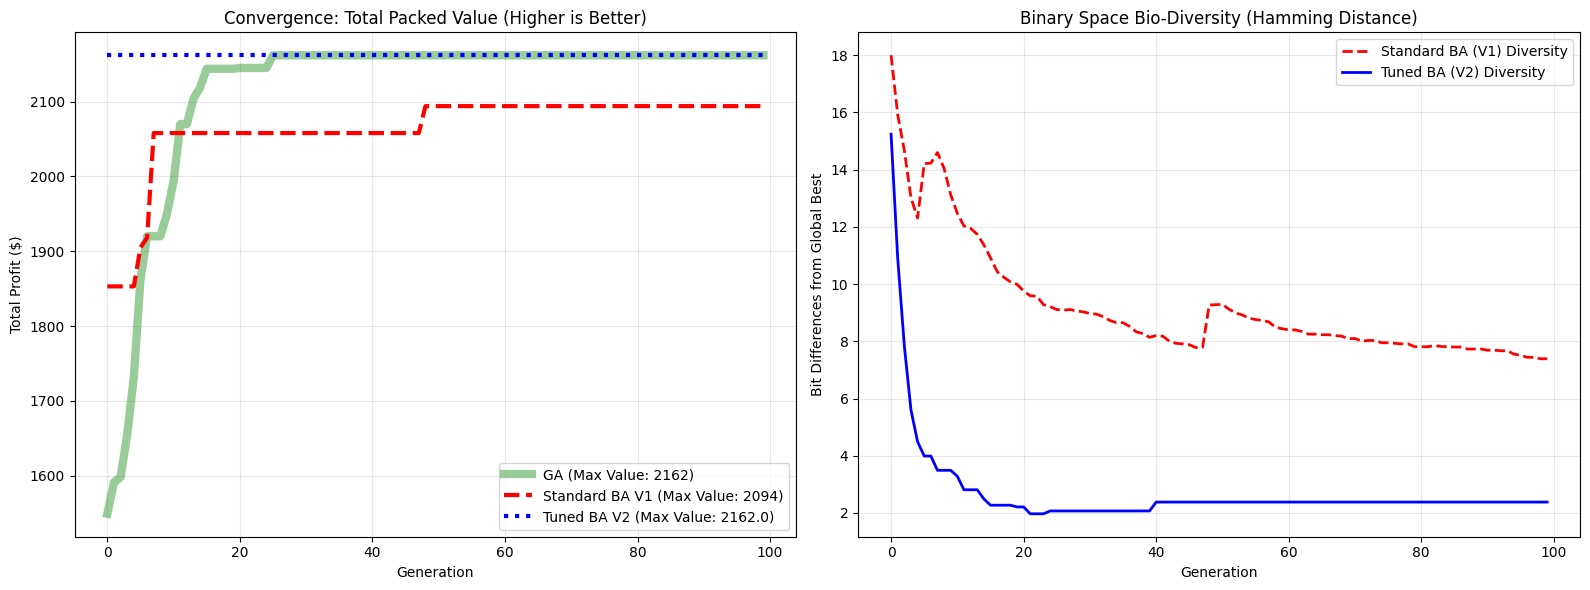

In [18]:
print("Generating Heuristic Population...")
smart_pop = smart_initialization_knapsack(pop_size=POPULATION_SIZE, num_items=NUM_ITEMS)

# 1. Run Baseline GA
start = time.time()
ga_best, ga_conv, ga_pos, ga_fit = genetic_algorithm()
ga_time = time.time() - start

# 2. Run Standard BA (V1)
start = time.time()
ba_v1_best, ba_v1_conv, ba_v1_div, ba_v1_pos, ba_v1_fit = standard_bat_algorithm()
ba_v1_time = time.time() - start

# 3. Run Enhanced BA (V2)
start = time.time()
ba_v2_best, ba_v2_conv, ba_v2_div, ba_v2_pos, ba_v2_fit = enhanced_bat_algorithm(
    init_pop=smart_pop, 
    a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
    f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA
)
ba_v2_time = time.time() - start

# --- HELPER TO CALCULATE AVERAGES EXCLUDING FATAL PENALTIES ---
def get_valid_avg(fitness_array):
    valid_scores = [-f for f in fitness_array if f < 0]
    return np.mean(valid_scores) if valid_scores else 0

# --- PRINTING THE PERFORMANCE SUMMARY TABLE ---
print("\n--- ALGORITHM PERFORMANCE SUMMARY ---")
header = f"| {'Algorithm':<20} | {'Pop':<4} | {'Gen':<4} | {'Weight Used':<14} | {'Final Max Value':<16} | {'Final Avg Value':<16} | {'Total Time':<11} | {'Avg Gen Time':<12} |"
print("=" * len(header))
print(header)
print("=" * len(header))

metrics = [
    ("Standard BA (V1)", POPULATION_SIZE, MAX_GENERATIONS, f"{np.sum(ba_v1_pos * WEIGHTS):.0f}/{CAPACITY:.0f}", f"${-ba_v1_best if ba_v1_best < 0 else 0:.0f}", f"${get_valid_avg(ba_v1_fit):.2f}", ba_v1_time),
    ("Enhanced BA (V2)", POPULATION_SIZE, MAX_GENERATIONS, f"{np.sum(ba_v2_pos * WEIGHTS):.0f}/{CAPACITY:.0f}", f"${-ba_v2_best if ba_v2_best < 0 else 0:.0f}", f"${get_valid_avg(ba_v2_fit):.2f}", ba_v2_time),
    ("Genetic Algorithm", POPULATION_SIZE, MAX_GENERATIONS, f"{np.sum(ga_pos * WEIGHTS):.0f}/{CAPACITY:.0f}", f"${-ga_best if ga_best < 0 else 0:.0f}", f"${get_valid_avg(ga_fit):.2f}", ga_time)
]

for m in metrics:
    print(f"| {m[0]:<20} | {m[1]:<4} | {m[2]:<4} | {m[3]:<14} | {m[4]:<16} | {m[5]:<16} | {m[6]:<10.4f}s | {m[6]/MAX_GENERATIONS:<11.5f}s |")
print("=" * len(header))

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(ga_conv, label=f'GA (Max Value: {-ga_best if ga_best < 0 else 0})', color='green', linewidth=6, alpha=0.4)
ax1.plot(ba_v1_conv, label=f'Standard BA V1 (Max Value: {-ba_v1_best if ba_v1_best < 0 else 0})', color='red', linestyle='--', linewidth=3)
ax1.plot(ba_v2_conv, label=f'Tuned BA V2 (Max Value: {-ba_v2_best if ba_v2_best < 0 else 0})', color='blue', linestyle=':', linewidth=3)
ax1.set_title("Convergence: Total Packed Value (Higher is Better)")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Total Profit ($)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(ba_v1_div, label='Standard BA (V1) Diversity', color='red', linestyle='--', linewidth=2)
ax2.plot(ba_v2_div, label='Tuned BA (V2) Diversity', color='blue', linewidth=2)
ax2.set_title("Binary Space Bio-Diversity (Hamming Distance)")
ax2.set_xlabel("Generation")
ax2.set_ylabel("Bit Differences from Global Best")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Generating Binary Bio-Diversity Matrix (Standard BA)...


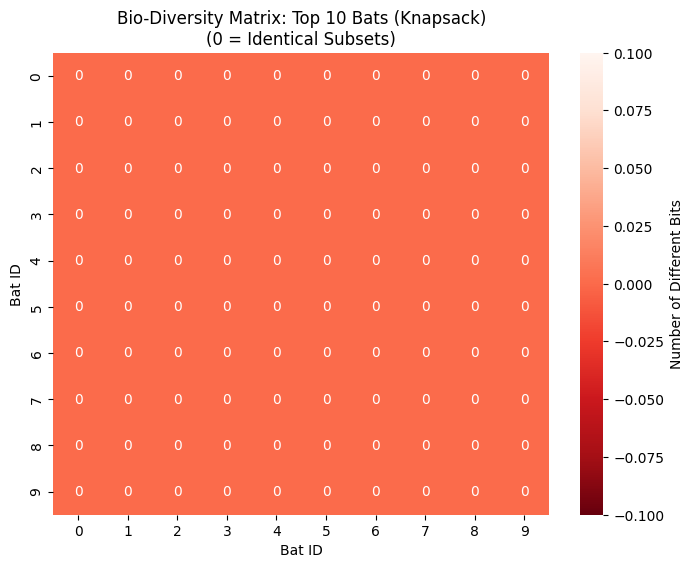

In [19]:
print("Generating Binary Bio-Diversity Matrix (Standard BA)...")

pop_size_matrix = 20
positions_matrix = np.array([np.random.randint(0, 2, NUM_ITEMS) for _ in range(pop_size_matrix)], dtype=float)
velocities_matrix = np.zeros((pop_size_matrix, NUM_ITEMS))
best_pos = positions_matrix[0].copy()

for gen in range(50):
    for i in range(pop_size_matrix):
        velocities_matrix[i] += (positions_matrix[i] - best_pos) * random.uniform(0, 2.0)
        sigmoid = 1 / (1 + np.exp(-velocities_matrix[i]))
        positions_matrix[i] = np.where(np.random.random(NUM_ITEMS) < sigmoid, 1, 0)
        
        if fitness_knapsack(positions_matrix[i]) < fitness_knapsack(best_pos):
            best_pos = positions_matrix[i].copy()

fitness_scores = [fitness_knapsack(p) for p in positions_matrix]
top_10_indices = np.argsort(fitness_scores)[:10]
top_10_bats = positions_matrix[top_10_indices]

dist_matrix = squareform(pdist(top_10_bats, metric='hamming')) * NUM_ITEMS

plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, cmap="Reds_r", cbar_kws={'label': 'Number of Different Bits'})
plt.title("Bio-Diversity Matrix: Top 10 Bats (Knapsack)\n(0 = Identical Subsets)")
plt.xlabel("Bat ID")
plt.ylabel("Bat ID")
plt.show()

In [20]:
print("==================================================")
print("   SCALABILITY STRESS TEST (V2: TUNED + SMART)    ")
print("==================================================")

item_sizes = [20, 40, 60, 80, 100]
runs_per_size = 10
results = []

# Backup the global variables
original_weights, original_values, original_capacity = WEIGHTS.copy(), VALUES.copy(), CAPACITY

for size in item_sizes:
    print(f"\n[>>>] Stressing {size}-Item Knapsack (Constrained Population: 30)...")
    
    # FIX: We safely override the global variables so `smart_initialization` works perfectly!
    global WEIGHTS, VALUES, CAPACITY
    WEIGHTS = np.random.randint(1, 20, size)
    VALUES = np.random.randint(10, 100, size)
    CAPACITY = np.sum(WEIGHTS) * 0.5
    
    avg_values = []
    start_time = time.time()
    
    for run in range(runs_per_size):
        test_pop = smart_initialization_knapsack(pop_size=30, num_items=size)
        
        best_val, _, _, _, _ = enhanced_bat_algorithm(
            n_items=size, pop_size=30, max_gens=100, 
            a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
            f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA, 
            init_pop=test_pop
        )
        
        actual_profit = -best_val if best_val < 0 else 0
        avg_values.append(actual_profit)
        print(f"      Run {run+1}/10: [COMPLETE] Max Profit Found: ${actual_profit:.0f}")
            
    exec_time = time.time() - start_time
    mean_profit = np.mean(avg_values)
    
    results.append([f"{size} Items", f"${mean_profit:.1f}", f"{exec_time:.2f}s"])

# Restore original global variables for safety
WEIGHTS, VALUES, CAPACITY = original_weights, original_values, original_capacity

print("\n--- FINAL SCALABILITY METRICS ---")
header = f"| {'Domain Complexity':<20} | {'Avg Max Profit':<18} | {'Total Exec Time':<15} |"
print("-" * len(header))
print(header)
print("-" * len(header))
for row in results:
    print(f"| {row[0]:<20} | {row[1]:<18} | {row[2]:<15} |")
print("-" * len(header))

   SCALABILITY STRESS TEST (V2: TUNED + SMART)    

[>>>] Stressing 20-Item Knapsack (Constrained Population: 30)...
      Run 1/10: [COMPLETE] Max Profit Found: $797
      Run 2/10: [COMPLETE] Max Profit Found: $803
      Run 3/10: [COMPLETE] Max Profit Found: $806
      Run 4/10: [COMPLETE] Max Profit Found: $806
      Run 5/10: [COMPLETE] Max Profit Found: $803
      Run 6/10: [COMPLETE] Max Profit Found: $779
      Run 7/10: [COMPLETE] Max Profit Found: $803
      Run 8/10: [COMPLETE] Max Profit Found: $803
      Run 9/10: [COMPLETE] Max Profit Found: $803
      Run 10/10: [COMPLETE] Max Profit Found: $806

[>>>] Stressing 40-Item Knapsack (Constrained Population: 30)...
      Run 1/10: [COMPLETE] Max Profit Found: $1494
      Run 2/10: [COMPLETE] Max Profit Found: $1525
      Run 3/10: [COMPLETE] Max Profit Found: $1477
      Run 4/10: [COMPLETE] Max Profit Found: $1525
      Run 5/10: [COMPLETE] Max Profit Found: $1489
      Run 6/10: [COMPLETE] Max Profit Found: $1529
      Run 